<a href="https://colab.research.google.com/github/rashdiwsl/RA_Metadata_Model_Comparison/blob/main/RA_Metadata_Model_Comparison1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- Cell 2: Generate Synthetic RA Data ---
def generate_ra_metadata(n_rows=500, random_seed=42):
    np.random.seed(random_seed)
    data = {
        'Patient_ID': range(1, n_rows + 1),
        'Age': np.random.randint(30, 75, n_rows),
        'HR_Avg': np.random.normal(75, 10, n_rows),
        'HRV_Score': np.random.normal(50, 15, n_rows),
        'Temp_Env': np.random.normal(20, 5, n_rows),
        'Humidity': np.random.randint(30, 90, n_rows),
        'Stress_Index': np.random.uniform(0, 1, n_rows)
    }
    df = pd.DataFrame(data)

    # RA Flare probability logic
    flare_prob = (df['Stress_Index'] * 0.4) + \
                 ((100 - df['HRV_Score']) / 100 * 0.3) + \
                 (df['Humidity'] / 100 * 0.3)

    df['RA_Flare'] = (flare_prob > 0.6).astype(int)

    # Balance classes if necessary
    num_flares = df['RA_Flare'].sum()
    num_no_flares = n_rows - num_flares
    if abs(num_flares - num_no_flares) > n_rows * 0.1:
        print("Adjusting for class imbalance...")
        if num_flares < num_no_flares:
            no_flare_indices = df[df['RA_Flare'] == 0].index
            flip_count = (num_no_flares - num_flares) // 2
            flip_indices = np.random.choice(no_flare_indices, min(flip_count, len(no_flare_indices)), replace=False)
            df.loc[flip_indices, 'RA_Flare'] = 1
        else:
            flare_indices = df[df['RA_Flare'] == 1].index
            flip_count = (num_flares - num_no_flares) // 2
            flip_indices = np.random.choice(flare_indices, min(flip_count, len(flare_indices)), replace=False)
            df.loc[flip_indices, 'RA_Flare'] = 0

    print(f"Generated dataset with {n_rows} rows. Flare distribution: {df['RA_Flare'].value_counts().to_dict()}")
    return df

In [ ]:
# --- Cell 3: Generate Dataset ---
df = generate_ra_metadata(n_rows=500)

# Quick view
print("Sample of generated data:")
print(df.head())

Adjusting for class imbalance...
Generated dataset with 500 rows. Flare distribution: {1: 250, 0: 250}
Sample of generated data:
   Patient_ID  Age     HR_Avg  HRV_Score   Temp_Env  Humidity  Stress_Index  \
0           1   68  87.302114  45.383216   8.322136        71      0.522577   
1           2   58  62.087756  40.116524  17.503514        30      0.299566   
2           3   44  90.549227  59.956058  16.233509        86      0.076862   
3           4   72  65.187997  65.152122  23.946578        58      0.500624   
4           5   37  62.617691  36.970892  16.756687        74      0.794516   

   RA_Flare  
0         1  
1         0  
2         0  
3         0  
4         1  


In [ ]:
# --- Cell 4: Prepare Features & Target ---
X = df.drop(['Patient_ID', 'RA_Flare'], axis=1)
y = df['RA_Flare']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# --- Cell 5: Initialize Models ---
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [ ]:
# --- Cell 6: Train & Evaluate Models ---
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print("  Classification Report:")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)
print("\n--- Model Comparison Results ---")
print(results_df.round(4))


Training Logistic Regression...
  Accuracy: 0.7300
  F1-Score: 0.7379
  ROC-AUC: 0.8180
  Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        50
           1       0.72      0.76      0.74        50

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.73      0.73      0.73       100


Training Random Forest...
  Accuracy: 0.7800
  F1-Score: 0.7609
  ROC-AUC: 0.8140
  Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.86      0.80        50
           1       0.83      0.70      0.76        50

    accuracy                           0.78       100
   macro avg       0.79      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100


Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:23:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.7600
  F1-Score: 0.7500
  ROC-AUC: 0.8060
  Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        50
           1       0.78      0.72      0.75        50

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100


--- Model Comparison Results ---
                 Model  Accuracy  F1-Score  ROC-AUC
0  Logistic Regression      0.73    0.7379    0.818
1        Random Forest      0.78    0.7609    0.814
2              XGBoost      0.76    0.7500    0.806


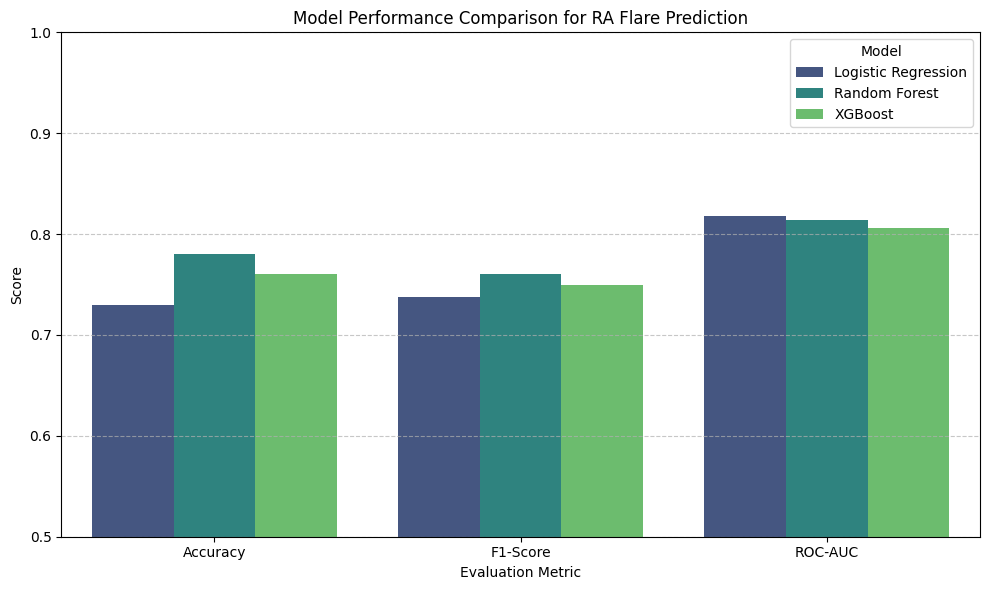

Model performance comparison chart saved as 'model_performance_comparison.png'


In [ ]:
# --- Cell 7: Visualization ---
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
results_df_melted = results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_df_melted, palette='viridis')
plt.title('Model Performance Comparison for RA Flare Prediction')
plt.ylim(0.5, 1.0)
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('model_performance_comparison.png')
plt.show()
print("Model performance comparison chart saved as 'model_performance_comparison.png'")